In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error , mean_squared_error

import warnings
warnings.filterwarnings('ignore')

In [112]:
df = pd.read_csv('Housing.csv')
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [113]:
x = df.iloc[:,1:]
x

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...
540,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [114]:
df.shape

(545, 13)

In [115]:
y = df.iloc[:,0]
y

0      13300000
1      12250000
2      12250000
3      12215000
4      11410000
         ...   
540     1820000
541     1767150
542     1750000
543     1750000
544     1750000
Name: price, Length: 545, dtype: int64

In [116]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 69.2 KB


In [117]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [118]:
nums_col= x.iloc[:, [0,1, 2, 3, 9]]
nums_col

,area,bedrooms,bathrooms,stories,parking
0,7420,4,2,3,2
1,8960,4,4,4,3
2,9960,3,2,2,2
3,7500,4,2,2,3
4,7420,4,1,2,2
...,...,...,...,...,...
540,3000,2,1,1,2
541,2400,3,1,1,0
542,3620,2,1,1,0
543,2910,3,1,1,0


In [119]:
str_column = x.iloc[:,[4,5,6,7,8,10]]
str_column

,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea
0,yes,no,no,no,yes,yes
1,yes,no,no,no,yes,no
2,yes,no,yes,no,no,yes
3,yes,no,yes,no,yes,yes
4,yes,yes,yes,no,yes,no
...,...,...,...,...,...,...
540,yes,no,yes,no,no,no
541,no,no,no,no,no,no
542,yes,no,no,no,no,no
543,no,no,no,no,no,no


In [120]:
le = LabelEncoder()

for col in str_column:
    str_column[col] = le.fit_transform(str_column[col])

str_column

,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea
0,1,0,0,0,1,1
1,1,0,0,0,1,0
2,1,0,1,0,0,1
3,1,0,1,0,1,1
4,1,1,1,0,1,0
...,...,...,...,...,...,...
540,1,0,1,0,0,0
541,0,0,0,0,0,0
542,1,0,0,0,0,0
543,0,0,0,0,0,0


In [121]:
X = pd.concat([nums_col, str_column], axis=1)
X

,area,bedrooms,bathrooms,stories,parking,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea
0,7420,4,2,3,2,1,0,0,0,1,1
1,8960,4,4,4,3,1,0,0,0,1,0
2,9960,3,2,2,2,1,0,1,0,0,1
3,7500,4,2,2,3,1,0,1,0,1,1
4,7420,4,1,2,2,1,1,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...
540,3000,2,1,1,2,1,0,1,0,0,0
541,2400,3,1,1,0,0,0,0,0,0,0
542,3620,2,1,1,0,1,0,0,0,0,0
543,2910,3,1,1,0,0,0,0,0,0,0


In [122]:
y

0      13300000
1      12250000
2      12250000
3      12215000
4      11410000
         ...   
540     1820000
541     1767150
542     1750000
543     1750000
544     1750000
Name: price, Length: 545, dtype: int64

In [123]:
# Now we are ready with our dataset
X_train,X_test,y_train , y_test = train_test_split(X ,y,test_size = 0.2,random_state = 41)
X_train.shape , X_test.shape , y_train.shape , y_test.shape


((436, 11), (109, 11), (436,), (109,))

In [124]:
X_train

,area,bedrooms,bathrooms,stories,parking,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea
29,5500,4,2,2,1,1,0,1,0,1,1
16,6600,4,2,2,1,1,1,1,0,1,1
110,6600,3,1,1,2,1,1,1,0,0,1
446,3986,2,2,1,1,0,1,1,0,0,0
223,6321,3,1,2,1,1,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...
469,4600,2,1,1,0,1,0,0,0,0,0
407,2145,3,1,3,0,1,0,0,0,0,1
243,2550,3,1,2,0,1,0,1,0,0,0
321,3630,3,2,2,2,1,0,0,1,0,0


# Linear Regression

In [125]:
model = LinearRegression()
model.fit(X_train,y_train)
model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [126]:
lr_pred = model.predict(X_test)
lr_pred

array([2942717.36103036, 4112455.46564894, 3569644.91787695,
       6763116.92648259, 2707318.46678973, 5363684.18252837,
       5034737.31012778, 4355987.17155912, 5440052.86096299,
       3331478.56471953, 3191616.32945403, 6408484.41973655,
       2679943.02389807, 3537749.75366943, 3384516.16124888,
       2953697.45281465, 3489736.88078458, 6294161.39182835,
       3364329.09618951, 5456402.06436654, 3781242.52128751,
       3650248.25381219, 4416089.4481126 , 4297841.46765645,
       3145107.99116584, 3536764.47177933, 5794327.23973865,
       3965929.72021486, 3879576.55380706, 8104344.52319252,
       2570331.51650587, 2827770.41551303, 2378485.85437386,
       5812745.25056398, 6455317.45951399, 7760319.06215516,
       2715531.09965723, 6678942.10308403, 5428307.98670036,
       3331627.61498483, 4346559.52388433, 5025655.29354917,
       3654291.22895067, 3411534.39179693, 4166212.01102467,
       3668618.21249131, 3815776.42738382, 7921728.51232873,
       6038481.68076888,

In [127]:
# Now we use the evaluation metrics to check how accurate the prediction of our it is
lr_r2 = r2_score(y_test,lr_pred)
print(f'The R2_score of model is : {lr_r2}')
print(f'The Mean Squared Error of model  is : {mean_absolute_error(y_test,lr_pred)}')
print(f'Root Mean Squared Error of model is :{np.sqrt(mean_squared_error(y_test, lr_pred))}')

The R2_score of model is : 0.5919214673068186
The Mean Squared Error of model  is : 842170.5963163162
Root Mean Squared Error of model is :1140983.0874395291


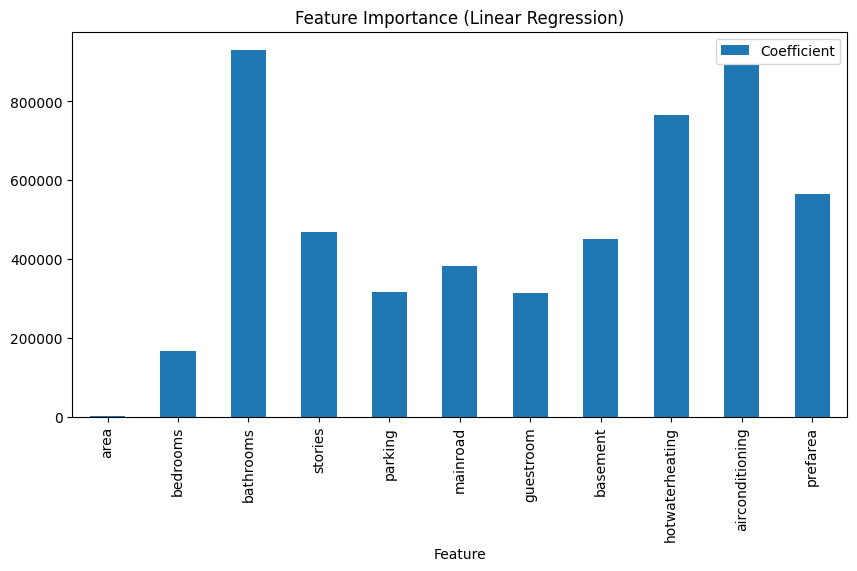

In [128]:
# Checking importance of features 

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})
feature_importance.plot(
    x='Feature',
    y='Coefficient',
    kind='bar',
    figsize=(10,5)
)

plt.title('Feature Importance (Linear Regression)')
plt.show()

# Random Forest Regressor model

In [143]:
model2 = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model2.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [130]:
rf_pred = model2.predict(X_test)
rf_pred

array([ 3123023.75      ,  3968154.16666667,  3573185.        ,
        6279764.4       ,  3129308.75      ,  5331480.        ,
        4649680.        ,  5402185.83333333,  5524225.        ,
        3829595.        ,  3388746.66666667,  5506882.5       ,
        2941825.83333333,  4392710.        ,  3478895.        ,
        2913155.        ,  3679397.75      ,  5810385.        ,
        4234895.        ,  5644590.        ,  4023054.58333333,
        3662408.75      ,  5223172.5       ,  3761280.83333333,
        3627400.        ,  4483605.        ,  4354490.        ,
        3850772.91666667,  4245395.        ,  9984132.2       ,
        3077340.        ,  3510180.        ,  2742969.25      ,
        4597040.        ,  7265924.4       , 10170078.8       ,
        2742627.5       ,  4315430.        ,  4777780.        ,
        3766455.        ,  3803178.75      ,  5809090.        ,
        3903375.        ,  3157420.        ,  3498390.        ,
        3303996.5       ,  4317670.     

In [131]:
rf_r2 = r2_score(y_test, rf_pred)
print(f'The R2_score of model is : {rf_r2}')
print(f'The Mean Squared Error of model  is : {mean_absolute_error(y_test, rf_pred)}')
print(f'Root Mean Squared Error of model is :{np.sqrt(mean_squared_error(y_test, rf_pred))}')

The R2_score of model is : 0.546278371393871
The Mean Squared Error of model  is : 855481.9446483181
Root Mean Squared Error of model is :1203100.9609371792


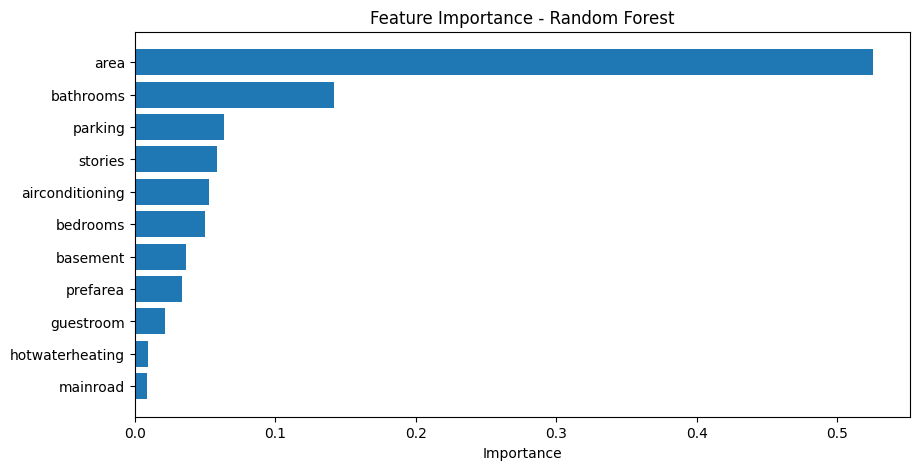

In [137]:
# Checking importtance of our features 
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model2.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)
plt.figure(figsize=(10,5))

plt.barh(
    importance['Feature'],
    importance['Importance']
)

plt.xlabel('Importance')
plt.title('Feature Importance - Random Forest')

plt.gca().invert_yaxis()
plt.show()

# Chart 1:Histogram showing the distribution of house prices

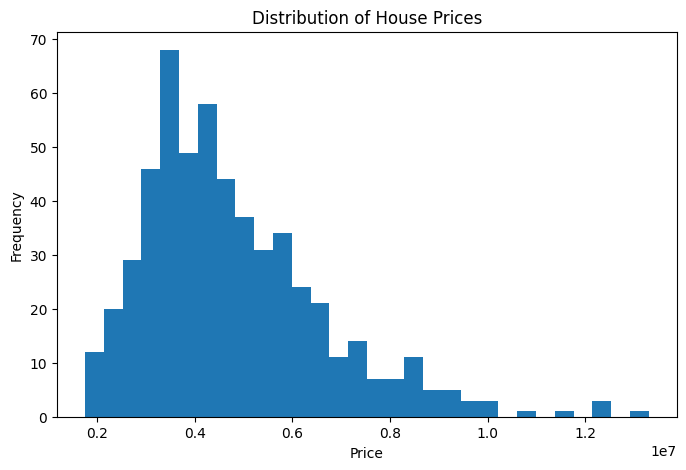

In [138]:

plt.figure(figsize=(8,5))
plt.hist(df['price'], bins=30)
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')

plt.savefig('house_price_histogram.png', dpi=300, bbox_inches='tight')
plt.show()

# Chart 2: Correlation heatmap showing which features relate most strongly to price 

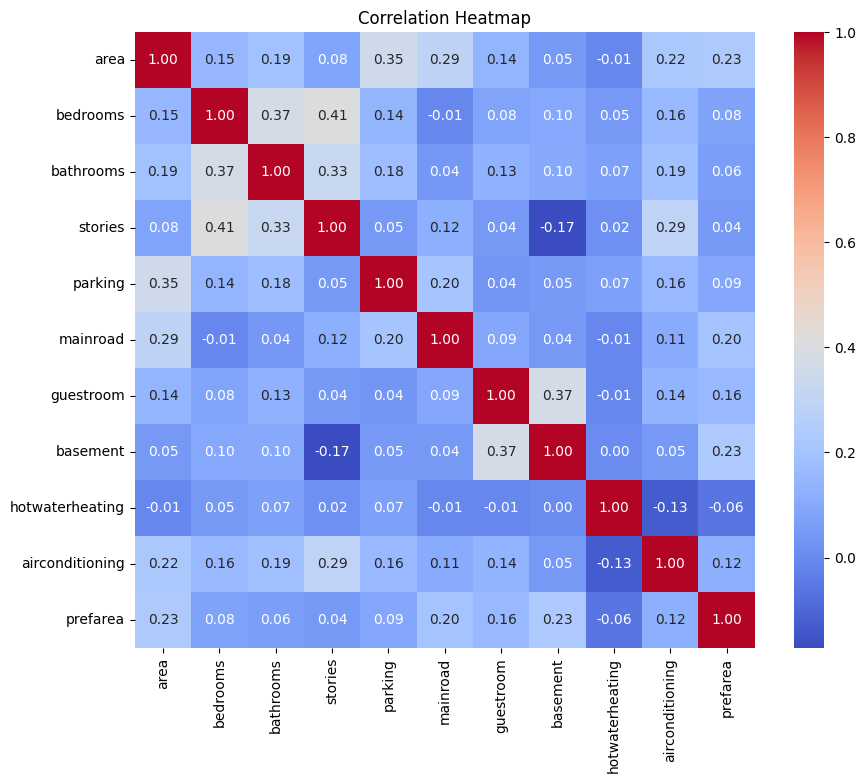

In [139]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(X.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title('Correlation Heatmap')
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# Chart 3:Actual vs Predicted House Prices

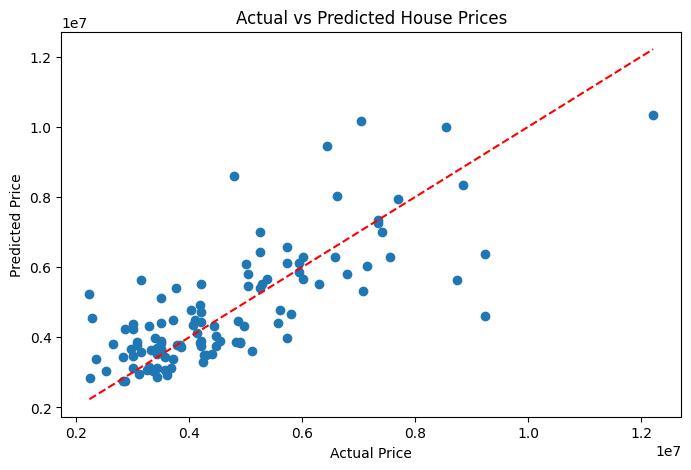

In [141]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted House Prices')

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.savefig('actual_vs_predicted.png', dpi=300, bbox_inches='tight')
plt.show()

#Points closer to the red line indicate better predictions.

# Comparing Regression and RandomForest Models

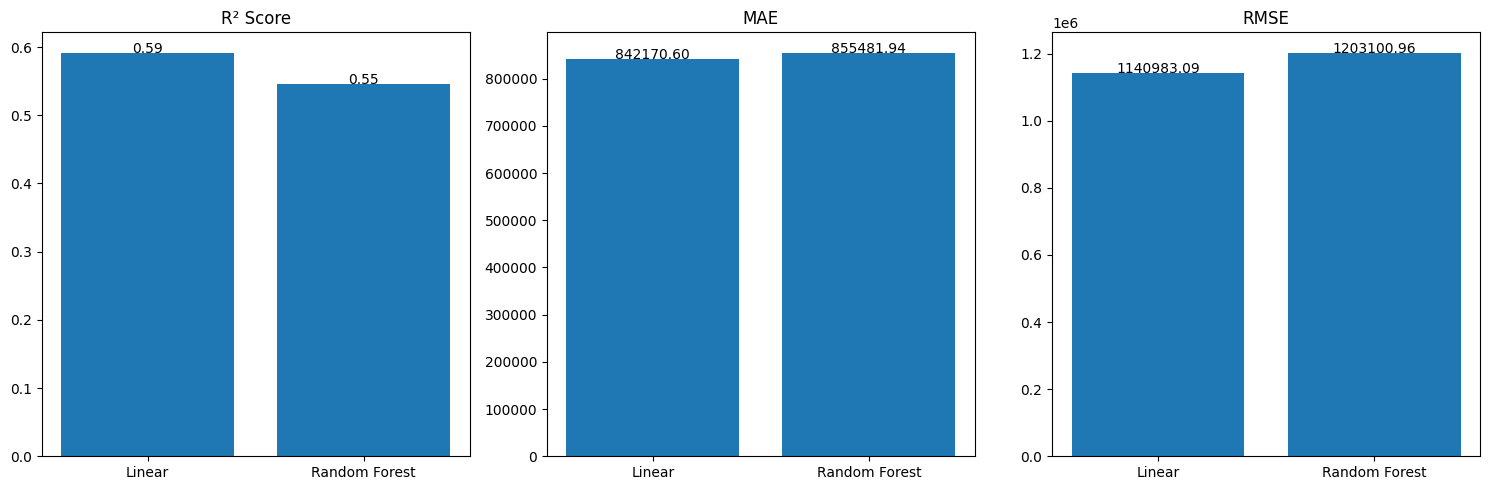

In [142]:

fig, ax = plt.subplots(1, 3, figsize=(15, 5))

metrics = {
    'R² Score': [lr_r2, rf_r2],
    'MAE': [lr_mae, rf_mae],
    'RMSE': [lr_rmse, rf_rmse]
}

for i, (title, values) in enumerate(metrics.items()):
    bars = ax[i].bar(['Linear', 'Random Forest'], values)
    ax[i].set_title(title)

    for bar in bars:
        ax[i].text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f'{bar.get_height():.2f}',
            ha='center'
        )

plt.tight_layout()
plt.show()